# This notebook is used to generate figures for the presentation on ExactBO

## 1 - BO vs ExactBO Domain Management

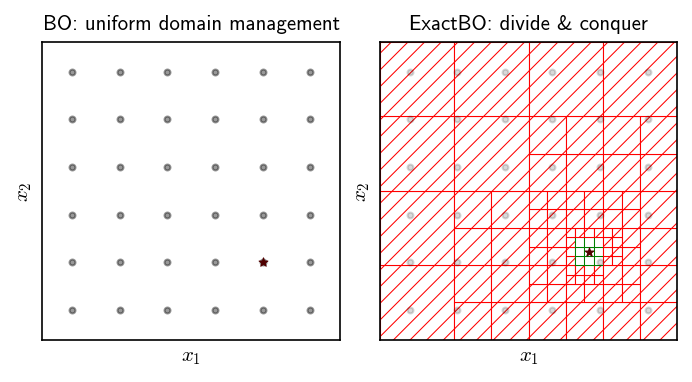

In [70]:
# Matplotlib figure for BO vs ExactBO (1x2), CM Sans, 10pt, 4.5x3.5 in
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# --- typography & style ---
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif", "CMU Sans Serif", "CMU Sans", "cmss10", "cmss"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "cm",
    "mathtext.sf": "cmss",
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Set global hatch linewidth
plt.rcParams['hatch.linewidth'] = 0.5

# LaTeX rendering optional (turn on if your env supports it)
# mpl.rcParams.update({
#     "text.usetex": True,
#     "text.latex.preamble": r"\usepackage{sfmath}\renewcommand{\familydefault}{\sfdefault}"
# })

aggiemaroon = np.array([[80/255, 0, 0]])

fig, axs = plt.subplots(1, 2, figsize=(4.5, 2.4), constrained_layout=True)

# Common axis setup
for ax in axs:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)

# --- Left: BO grid with best next point ---
ax = axs[0]
ax.set_title("BO: uniform domain management")

# grid points
gx = np.linspace(0.1, 0.9, 6)
gy = np.linspace(0.1, 0.9, 6)
X, Y = np.meshgrid(gx, gy)
ax.scatter(X, Y, s=8, c="black", alpha=0.4)

# best next point (star)
best_pt_BO = (0.74, 0.26)
ax.scatter(*best_pt_BO, s=20, marker="*", c=aggiemaroon, edgecolor=aggiemaroon, linewidth=0.5, zorder=5)

# --- Right: ExactBO divide & conquer (recursive tiling) ---
ax = axs[1]
ax.set_title("ExactBO: divide & conquer")

best_pt = (0.7, 0.3)
active_color = (0.0, 0.5, 0.0)

def subdivide(x, y, w, h, depth, max_depth, focus_pt, focus_radius):
    """Recursive quadtree subdivision."""
    cx = x + w / 2
    cy = y + h / 2
    dist = ((cx - focus_pt[0])**2 + (cy - focus_pt[1])**2) ** 0.5

    # Decide whether to subdivide further
    if depth < max_depth and dist < focus_radius * (2 ** (max_depth - depth)):
        # split into 4
        hw, hh = w / 2, h / 2
        subdivide(x,     y,     hw, hh, depth+1, max_depth, focus_pt, focus_radius)
        subdivide(x+hw,  y,     hw, hh, depth+1, max_depth, focus_pt, focus_radius)
        subdivide(x,     y+hh,  hw, hh, depth+1, max_depth, focus_pt, focus_radius)
        subdivide(x+hw,  y+hh,  hw, hh, depth+1, max_depth, focus_pt, focus_radius)
    else:
        # leaf tile
        is_active = (dist < focus_radius)
        if is_active:
            ax.add_patch(Rectangle((x, y), w, h, facecolor="white",
                                   edgecolor=active_color, linewidth=0.5))
        else:
            ax.add_patch(Rectangle((x, y), w, h, facecolor="white",
                                   edgecolor="red", linewidth=0.5))
            ax.add_patch(Rectangle((x, y), w, h, facecolor="none",
                                   edgecolor="red", linewidth=0.5, hatch="///"))

# Parameters for the recursive look
subdivide(0.0, 0.0, 1.0, 1.0, depth=0, max_depth=5, focus_pt=best_pt, focus_radius=0.05)

# best point (same star)
best_pt_eBO = (0.703, 0.294)
ax.scatter(X, Y, s=8, c="black", alpha=0.15)
ax.scatter(*best_pt_eBO, s=20, marker="*", c=aggiemaroon, edgecolor=aggiemaroon, linewidth=0.5, zorder=5)

plt.show()
fig.savefig("Figures/bo_vs_exactbo.png", dpi=500)
fig.savefig("Figures/bo_vs_exactbo_transparent.png", dpi=500, transparent=True)

## 2 - Kernel Bounding

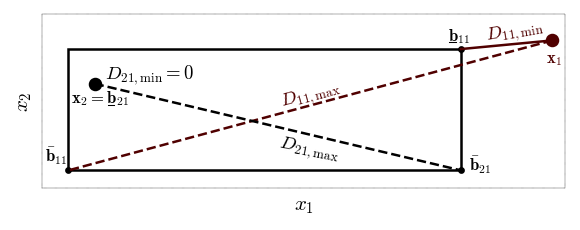

In [94]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# Style consistent with your deck
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif", "CMU Sans Serif", "CMU Sans", "cmss10", "cmss"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "cm",
    "mathtext.sf": "cmss",
})

aggiemaroon = np.array([[80/255, 0, 0]])

fig, ax = plt.subplots(1, 1, figsize=(4.5, 1.5))

# Hyperbox
box = (0.1, 0.1, 1.5, 0.7)  # x, y, w, h
ax.add_patch(Rectangle((box[0], box[1]), box[2], box[3],
                       facecolor="white", edgecolor="black", linewidth=1.2))
ax.scatter([box[0], box[0]+box[2], box[0]+box[2]], [box[1], box[1], box[1]+box[3]], s=5, c="black")  # bottom corners

# Points
p1 = (1.95, 0.85)  # outside
p2 = (0.20, 0.6)  # inside
ax.scatter(*p1, s=30, c=aggiemaroon, zorder=5)
ax.text(p1[0]-0.025, p1[1] - 0.13, r"$\mathbf{x}_1$", color=aggiemaroon, fontsize=8)
ax.scatter(*p2, s=30, c="black", zorder=5)
ax.text(p2[0]-0.09, p2[1] - 0.11, r"$\mathbf{x}_2=\mathbf{b}_{21}$", color="black", fontsize=8)
ax.plot([p2[0]+0.05, p2[0]+0.075], [p2[1]-0.12, p2[1]-0.12], color="black", linewidth=0.5)

# Min/max distance lines for p1 (outside)
# Min distance: to closest corner/edge (approx: to top-right corner here)
closest = (box[0] + box[2], box[1] + box[3])
ax.plot([p1[0], closest[0]], [p1[1], closest[1]], color=aggiemaroon, linewidth=1.2)
ax.text((p1[0]+closest[0])/2 + 0.03, (p1[1]+closest[1])/2 + 0.03, r"$D_{11,\min}$",
        color=aggiemaroon, ha="center", rotation=10, fontsize=9)
ax.text(closest[0]-0.05, closest[1] + 0.05, r"$\mathbf{b}_{11}$", color="black", fontsize=8)
ax.plot([closest[0]-0.045, closest[0]-0.02], [closest[1]+0.04, closest[1]+0.04], color="black", linewidth=0.5)

# Max distance: to farthest corner
farthest = (box[0], box[1])
ax.plot([p1[0], farthest[0]], [p1[1], farthest[1]], color=aggiemaroon,
        linewidth=1.2, linestyle="--")
ax.text((p1[0]+farthest[0])/2, (p1[1]+farthest[1])/2, r"$D_{11,\max}$",
        color=aggiemaroon, ha="center", rotation=15, fontsize=9)
ax.text(farthest[0]-0.09, farthest[1]+0.05, r"$\bar{\mathbf{b}}_{11}$", color="black", fontsize=8)

# Min/max distance lines for p2 (inside)
# Min distance: zero (point inside)
ax.text(p2[0] + 0.04, p2[1] + 0.03, r"$D_{21,\min}=0$", color="black", fontsize=9)

# Max distance: to farthest corner
farthest2 = (box[0] + box[2], box[1])
ax.plot([p2[0], farthest2[0]], [p2[1], farthest2[1]], color="black",
        linewidth=1.2, linestyle="--")
ax.text((p2[0]+farthest2[0])/2+0.12, (p2[1]+farthest2[1])/2 - 0.18, r"$D_{21,\max}$",
        color="black", ha="center", rotation=-11, fontsize=9)
ax.text(farthest2[0]+0.03, farthest2[1], r"$\bar{\mathbf{b}}_{21}$", color="black", fontsize=8)

# Axes and cleanup
ax.set_xlim(0, 2)
ax.set_ylim(0, 1)
#ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.2)
    spine.set_linestyle("dotted")

fig.savefig("Figures/kernel_bounds.png", dpi=500)  # no tight bbox to avoid clipping
fig.savefig("Figures/kernel_bounds_transparent.png", dpi=500, transparent=True)
plt.show()


## 3 - Normal PDF and CDF

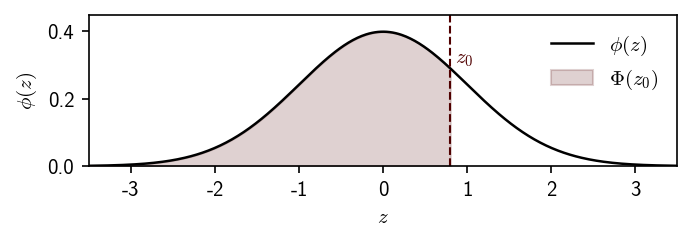

In [104]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from math import erf, sqrt

# Same typography/style as previous cells
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif", "CMU Sans Serif", "CMU Sans", "cmss10", "cmss"],
    "mathtext.fontset": "cm",
    "mathtext.rm": "cm",
    "mathtext.sf": "cmss",
    "axes.unicode_minus": False,
})

aggiemaroon = np.array([[80/255, 0, 0]])

def phi(z):
    return 1 / np.sqrt(2 * np.pi) * np.exp(-0.5 * z**2)

def Phi(z):
    return 0.5 * (1 + erf(z / sqrt(2)))

z = np.linspace(-3.5, 3.5, 400)
z0 = 0.8  # pick any example cutoff

fig, ax = plt.subplots(figsize=(4.5, 1.5), constrained_layout=True)
ax.plot(z, phi(z), color="black", lw=1.2, label=r"$\phi(z)$")

# shade Φ(z0)
mask = z <= z0
ax.fill_between(z[mask], phi(z)[mask], color=aggiemaroon[0], alpha=0.18,
                label=rf"$\Phi(z_0)$")
ax.axvline(z0, color=aggiemaroon[0], lw=1.0, ls="--")
ax.text(z0 + 0.05, phi(z0) + 0.015, rf"$z_0$", color=aggiemaroon[0])

ax.set_xlim(-3.5, 3.5)
ax.set_ylim(0, 0.45)
ax.set_xlabel(r"$z$")
ax.set_ylabel(r"$\phi(z)$")
ax.legend(frameon=False)
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.8)

plt.show()
fig.savefig("Figures/phi_cdf_shaded_transparent.png", dpi=500, transparent=True)
fig.savefig("Figures/phi_cdf_shaded.png", dpi=500)


## 4 - DIRECT Algorithm

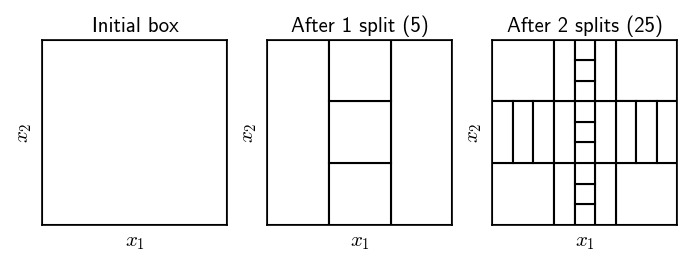

In [117]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# (Optional) keep the same style block you used earlier
mpl.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.size": 10, "font.family": "sans-serif",
    "font.sans-serif": ["Computer Modern Sans Serif", "CMU Sans Serif", "CMU Sans", "cmss10", "cmss"],
    "mathtext.fontset": "cm", "mathtext.rm": "cm", "mathtext.sf": "cmss",
    "axes.unicode_minus": False,
})

def subdivide_direct(rect):
    """DIRECT-style split: split longest side into thirds; split the middle slab along the other axis into thirds."""
    x, y, w, h = rect
    if w >= h:
        # split along x, then split middle third along y
        w3 = w / 3
        left   = (x,          y, w3, h)
        right  = (x + 2*w3,   y, w3, h)
        mid_x  = (x + w3,     y, w3, h)
        h3 = h / 3
        mid_b  = (mid_x[0], y,        w3, h3)
        mid_m  = (mid_x[0], y + h3,   w3, h3)
        mid_t  = (mid_x[0], y + 2*h3, w3, h3)
        return [left, right, mid_b, mid_m, mid_t]
    else:
        # split along y, then split middle third along x
        h3 = h / 3
        bottom = (x, y,        w, h3)
        top    = (x, y + 2*h3, w, h3)
        mid_y  = (x, y + h3,   w, h3)
        w3 = w / 3
        mid_l  = (x,        mid_y[1], w3, h3)
        mid_m  = (x + w3,   mid_y[1], w3, h3)
        mid_r  = (x + 2*w3, mid_y[1], w3, h3)
        return [bottom, top, mid_l, mid_m, mid_r]

stage0 = [(0.0, 0.0, 1.0, 1.0)]
stage1 = subdivide_direct(stage0[0])                    # 5 boxes
stage2 = [c for r in stage1 for c in subdivide_direct(r)]  # 25 boxes


stages = [stage0, stage1, stage2]

fig, axs = plt.subplots(1, 3, figsize=(4.5, 1.6), constrained_layout=True)
titles = ["Initial box", "After 1 split (5)", "After 2 splits (25)"]

for ax, rects, title in zip(axs, stages, titles):
    for (x, y, w, h) in rects:
        ax.add_patch(Rectangle((x, y), w, h, facecolor="white",
                               edgecolor="black", linewidth=1.0))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(r"$x_1$"); ax.set_ylabel(r"$x_2$")
    ax.set_title(title, pad=4, fontsize=10)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)

plt.show()
fig.savefig("Figures/direct_splits.png", dpi=500)
fig.savefig("Figures/direct_splits_transparent.png", dpi=500, transparent=True)
